Dataset: https://www.kaggle.com/datasets/yasserh/advertising-sales-dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np
from scipy import stats
from sklearn.metrics import r2_score

sns.set_palette(palette=sns.color_palette("Spectral"))


%matplotlib inline

In [2]:
df = pd.read_csv("Advertising Budget and Sales.csv")

df.drop("Unnamed: 0", axis=1, inplace=True)
df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
for col in df.columns:
    print(repr(col))

'TV Ad Budget ($)'
'Radio Ad Budget ($)'
'Newspaper Ad Budget ($)'
'Sales ($)'


In [4]:
col_rename = {col: f"X{idx}" for idx, col in enumerate(df.columns) if col != 'Sales ($)'}
col_rename['Sales ($)'] = "y"

df.rename(col_rename, axis=1, inplace=True)

print(f"Columns renamed as : {col_rename}")

df.head(3)

Columns renamed as : {'TV Ad Budget ($)': 'X0', 'Radio Ad Budget ($)': 'X1', 'Newspaper Ad Budget ($)': 'X2', 'Sales ($)': 'y'}


,X0,X1,X2,y
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X0      200 non-null    float64
 1   X1      200 non-null    float64
 2   X2      200 non-null    float64
 3   y       200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


<Axes: >

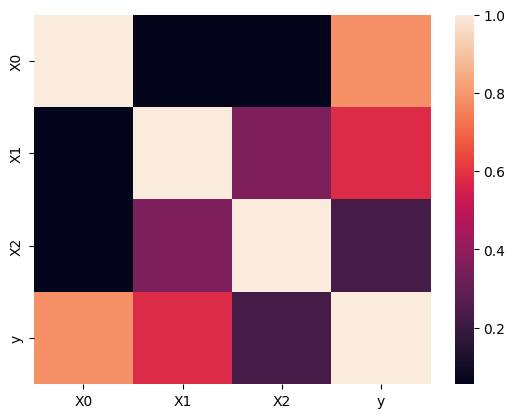

In [6]:
sns.heatmap(df.corr())

In [7]:
# sns.pairplot(df)

In [8]:
print(f"Independent Variables: {[col for col in df.columns if col != "y"]}")
print("Dependent Variable: y")

Independent Variables: ['X0', 'X1', 'X2']
Dependent Variable: y


In [9]:
X = df[[col for col in df.columns if col != "y"]]
y = df["y"]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True, random_state=42)

X_train.shape

(140, 3)

In [10]:
scalar = StandardScaler()

X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [11]:
model = LinearRegression().fit(X_train, y_train)

print(f"Coefficients are: {model.coef_}")
print(f"Intercept is: {model.intercept_}")

Coefficients are: [3.68334078 2.90625242 0.14194772]
Intercept is: 14.497142857142858


In [12]:
y_pred = model.predict(X_test)

# Ordinary Least Squares (OLS) – Mathematical Formulation

Let:

- $X$ be the $n \times k$ matrix of predictors (after scaling)  
- $y$ be the $n \times 1$ vector of responses  


### Design Matrix (with Intercept)

$$
X_d = [\mathbf{1} \mid X]
$$

Shape: $n \times p$, where

$$
p = k + 1
$$


### OLS Estimate

$$
\hat{\beta} = (X_d^\top X_d)^{-1} X_d^\top y
$$

We use the pseudo-inverse for numerical stability.

Model was trained using LinearRegression from scikit-learn linear_model
Which gave us $\beta$ and intercept using OLS, using which we will calculate follwing


### Fitted Values and Residuals

$$
\hat{y} = X_d \hat{\beta}
$$

$$
e = y - \hat{y}
$$


### Sum of Squared Errors (SSE)

$$
SSE = e^\top e
$$


### Estimated Variance of Residuals

$$
\hat{\sigma}^2 = \frac{SSE}{n - p}
$$


### Variance–Covariance Matrix of Coefficients

$$
\text{Var}(\hat{\beta}) =
\hat{\sigma}^2 (X_d^\top X_d)^{-1}
$$


### Standard Errors

$$
SE(\hat{\beta}_i) =
\sqrt{\text{diag}(\text{Var}(\hat{\beta}))}
$$


### t-Statistics

$$
t_i = \frac{\hat{\beta}_i}{SE(\hat{\beta}_i)}
$$

Degrees of freedom:

$$
df = n - p
$$


### Two-Sided p-values

$$
p_i = 2 \left( 1 - F_{t(df)}(|t_i|) \right)
$$


### Total Sum of Squares (TSS)

$$
TSS = \sum (y - \bar{y})^2
$$

$$
SSR = TSS - SSE
$$


### F-Statistic (Overall Model Significance)

$$
F =
\frac{SSR / (p - 1)}
{SSE / (n - p)}
$$

Degrees of freedom:

- $df_1 = p - 1$
- $df_2 = n - p$


### F-Test p-value

$$
p_F = 1 - F_{F(df_1, df_2)}(F)
$$


### Decision Rule

Let $\alpha = 0.05$

- If $p < \alpha$ → Reject $H_0$  
- If $p \ge \alpha$ → Fail to reject $H_0$

---

In [13]:
n = X_train.shape[0]
p = X_train.shape[1]

n, p

(140, 3)

In [14]:
intercept = model.intercept_     # scalar
beta = model.coef_               # array of length 8

# Compute Residuals
y_hat = model.predict(X_train)
residuals = y_train - y_hat

n = X_train.shape[0]
k = X_train.shape[1]
df_resid = n - k - 1


SSE = np.sum(residuals ** 2)
sigma2 = SSE / df_resid


# Standard errors of coefficients
X_design = np.column_stack((np.ones(n), X_train))

XtX_inv = np.linalg.inv(X_design.T @ X_design)

var_beta = sigma2 * XtX_inv
se_beta = np.sqrt(np.diag(var_beta))

### T Test:

Null Hypothesis ($H_0$): $H_0 : \beta_j = 0$

- There is no linear relationship between predictor $X_j$ and Sales (after controlling for other predictors).

Alternate Hypothesis ($H_1$): $H_1 : \beta \neq 0$

- There exists a statistically significant linear relationship between predictor $X_j$ and Sales.

In [15]:
# t-test for individual coefficients
t_stats = np.concatenate(([intercept], beta)) / se_beta

p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=df_resid))

names = ["Intercept"] + list(X.columns)

for name, t, p in zip(names, t_stats, p_values):
    decision = "Reject H0" if p < 0.05 else "Fail to reject H0"
    print(f"{name:10s}  t = {t:8.3f}  p = {p:.4f}  -> {decision}")

Intercept   t =  107.370  p = 0.0000  -> Reject H0
X0          t =   27.219  p = 0.0000  -> Reject H0
X1          t =   20.195  p = 0.0000  -> Reject H0
X2          t =    0.988  p = 0.3249  -> Fail to reject H0


From above we can see that X0 and X1 and the intercept have significant effect on the target or dependent variable (Sales)

### F Test:

Null Hypothesis ($H_0$): $H_0 : \beta_1 = \beta_2 = \beta_3 = 0$

- There is no linear relationship between predictor $X_j$ and Sales (after controlling for other predictors).

Alternate Hypothesis ($H_1$): $H_1 :$ Atleast one  $\beta_j \neq 0$

- There exists a statistically significant linear relationship between predictor $X_j$ and Sales.

In [16]:
# F-test for overall model significance
TSS = np.sum((y_train - y_train.mean())**2)
SSR = TSS - SSE

F_stat = (SSR / k) / (SSE / df_resid)
p_F = 1 - stats.f.cdf(F_stat, k, df_resid)

print("F =", F_stat)
print("Model p-value =", p_F)

if p_F < 0.05:
    print("Reject H0 -> Overall regression model is statistically significant")
else:
    print("Fail to reject H0 -> Model is not statistically significant")

F = 434.4654627620994
Model p-value = 0.0
Reject H0 -> Overall regression model is statistically significant


FThe regression model is statistically significant; at least one advertising medium contributes to explaining Sales.

## Coefficient of Determination ($R^2$)

In [17]:
# Training R^2
y_train_pred = model.predict(X_train)
r2 =r2_score(y_pred=y_train, y_true=y_train_pred)
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("For Training Data")
print(f"R^2 Score is : {r2}")
print(f"Adjusted R2 score is : {adj_r2}")

For Training Data
R^2 Score is : 0.8956572219915291
Adjusted R2 score is : 0.8900674303125039


In [18]:
r2 =r2_score(y_pred=y_pred, y_true=y_test)

n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"R^2 Score is : {r2}")
print(f"Adjusted R2 score is : {adj_r2}")

R^2 Score is : 0.8609466508230368
Adjusted R2 score is : 0.8534973642599852


# Residual Analysis

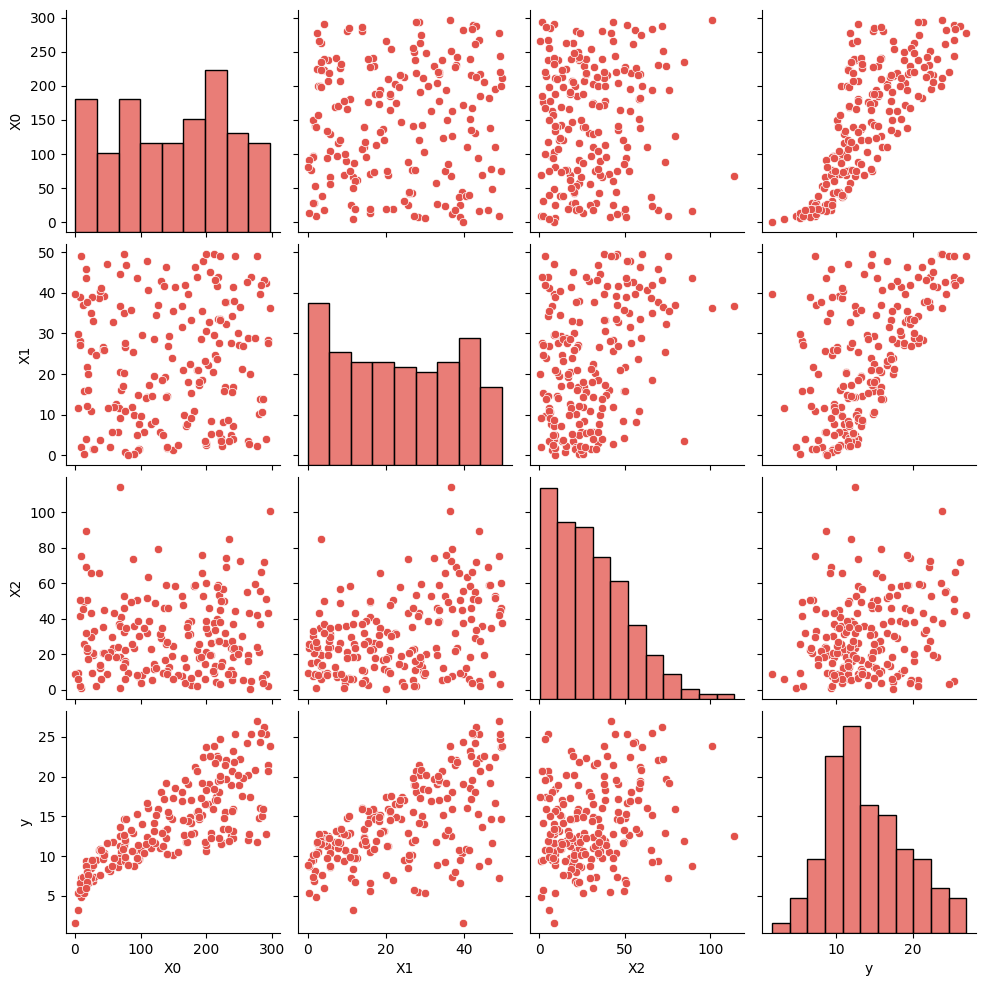

In [19]:
sns.pairplot(df)

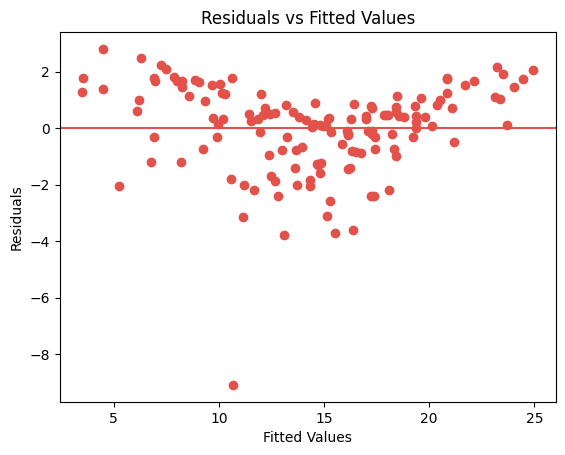

In [20]:
# Homoscedasticity

plt.figure()
plt.scatter(y_hat, residuals)
plt.axhline(y=0)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

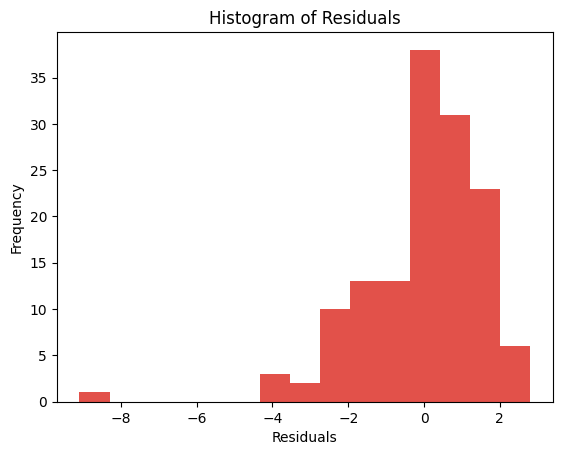

In [21]:
# Normality of Errors

plt.figure()
plt.hist(residuals, bins=15)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

# Performance Evaluation Metrics

In [22]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error is : {mae}")

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error is : {mse}")

rmse = root_mean_squared_error(y_test, y_pred)
print(f"Root Mean Squared Error is : {rmse}")

r2 = r2_score(y_test, y_pred)
print(f"R^2 error is : {r2}")

mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"Mean Absolute Percentage Error is : {mape}")

Mean Absolute Error is : 1.5116692224549084
Mean Squared Error is : 3.796797236715219
Root Mean Squared Error is : 1.9485372043446385
R^2 error is : 0.8609466508230368
Mean Absolute Percentage Error is : 0.16298720118158333


$R^2$ is about 0.86. The model explains about 86% of the variance in the held-out test data.

In [23]:
print("Regression Equation:")

equation = f"y_hat = {beta[0]:.4f} * X0"

for i in range(1, len(beta)):
    equation += f" + {beta[i]:.4f} * X{i}"

equation += f" + {model.intercept_}"
print(equation)

Regression Equation:
y_hat = 3.6833 * X0 + 2.9063 * X1 + 0.1419 * X2 + 14.497142857142858
